In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import sklearn.model_selection
import subprocess, tqdm, json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

#from aifes import keras2aifes

In [3]:
GPU_ID = 0
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus[GPU_ID], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[GPU_ID], True)
    except RuntimeError as e:
        print(e)

In [4]:
def imshow(img, title):
    plt.imshow(img, cmap = "binary")
    plt.title(str(title))
    plt.show()

def plot_value_array(i, predictions_array, true_label, num_classes):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(num_classes))
    plt.yticks([])
    thisplot = plt.bar(range(num_classes), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(predicted_label,
                                    100*np.max(predictions_array),
                                    true_label),
                                    color=color)

def plot_n_images(n, x, y):
    num_cols = 4
    assert (n % num_cols == 0)
    num_rows = n // num_cols
    plt.figure(figsize=(2*2*num_cols, 2*num_rows))
    for i in range(n):
        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        plt.subplot(num_rows, 2*num_cols, 2*i+2)
        plt.imshow(x[i])
        plt.title(str(y[i]))
        plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plt.tight_layout()
    plt.show()

def print_prediction(n, x_test, y_test, predictions, num_classes = 10):
    num_cols = 4
    assert (n % num_cols == 0)
    num_rows = n // num_cols
    plt.figure(figsize=(2*2*num_cols, 2*num_rows))
    for i in range(n):
        ind = np.random.randint(0, x_test.shape[0]-1)
        plt.subplot(num_rows, 2*num_cols, 2*i+1)
        plot_image(ind, predictions[ind], y_test, x_test)
        plt.subplot(num_rows, 2*num_cols, 2*i+2)
        plot_value_array(ind, predictions[ind], y_test, num_classes)
    plt.tight_layout()
    plt.show()

def plot_accuracy_loss(history, epochs, batch_size):
    stepX, stepY = 10, 0.025
    fig, axs = plt.subplots(2)
    axs[0].set_xticks(np.arange(0, epochs+stepX, stepX))
    axs[0].set_yticks(np.arange(0., 1.+stepY, stepY))
    axs[0].plot(history.epoch, history.history["accuracy"], 'g', label='Training accuracy')
    axs[0].plot(history.epoch, history.history["val_accuracy"], 'r', label='Validation accuracy')
    axs[0].set_title('Training & validation accuracy (batch_size = ' + str(batch_size) + ")")
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Accuracy')

    axs[1].set_xticks(np.arange(0, epochs+stepX, stepX))
    axs[1].plot(history.epoch, history.history["loss"], 'g', label='Training loss')
    axs[1].plot(history.epoch, history.history["val_loss"], 'r', label='Validation loss')
    axs[1].set_title('Training & validation loss (batch_size = ' + str(batch_size) + ")")
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Loss')
    fig.legend()
    plt.show()

def plot_dataset_balance(y, name):
    size           = y.shape[0]
    labels, counts = np.unique(y, return_counts = True)
    print("Minimum label occurence:", np.min(counts))
    plt.bar(labels, counts)
    plt.title(name + " set balance")
    plt.xlabel("Classes")
    plt.ylabel("Frequency")
    plt.show()


In [5]:
def balance_dataset(x, y):
    number_classes = np.unique(y).shape[0]
    min_occurence  = np.min(np.unique(y, return_counts = True)[1])
    x_bal, y_bal   = [], []
    for c in tqdm.trange(number_classes): # For every class
        c_idx = np.where(y == c)[0] # Filter data per class
        x_bal.append(x[c_idx][:min_occurence]) # Only keep the first min_occurence images of each class
        y_bal.append(y[c_idx][:min_occurence])
    x_bal = np.concatenate(x_bal)
    y_bal = np.concatenate(y_bal)
    return x_bal, y_bal

def to_categorical(y):
    return np.eye(np.unique(y).shape[0])[y]

def hwc_to_chw(x):
    return np.transpose(x, (0, 3, 1, 2))

def chw_to_hwc(x):
    return np.transpose(x, (0, 2, 3, 1))

def normalize_dataset(x):
    return (x / 255) - 0.5

def flatten_dataset(x):
    return np.reshape(x, (x.shape[0], np.prod(x.shape[1:])))

# MNIST dataset loading/processing

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set
(60000, 28, 28)
Minimum label occurence: 5421


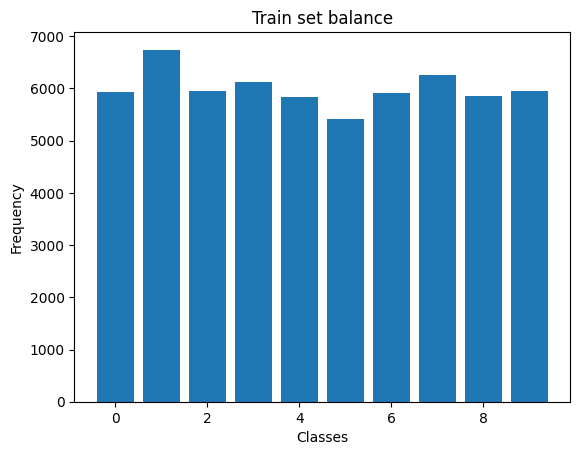

Testing set
(10000, 28, 28)
Minimum label occurence: 892


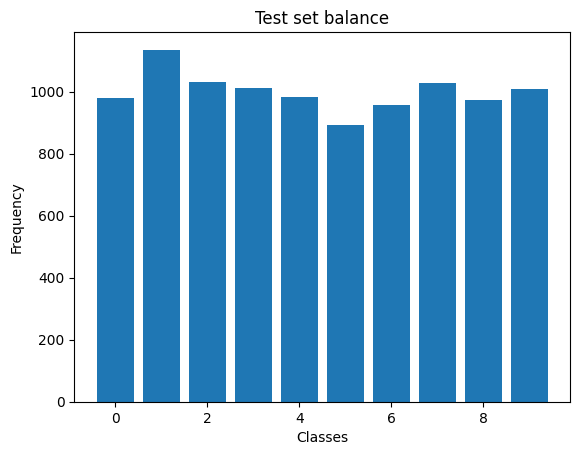

In [6]:
H, W, C     = 28, 28, 1
NUM_CLASSES = 10

# Building MNIST dataset
(x_mnist_train, y_mnist_train), (x_mnist_test, y_mnist_test) = tf.keras.datasets.mnist.load_data()

# Normalize dataset
x_mnist_train = normalize_dataset(x_mnist_train)
x_mnist_test = normalize_dataset(x_mnist_test)

print("Training set")
print(x_mnist_train.shape)
plot_dataset_balance(y_mnist_train, "Train")

print("Testing set")
print(x_mnist_test.shape)
plot_dataset_balance(y_mnist_test, "Test")

Balanced training set


100%|██████████| 10/10 [00:00<00:00, 35.41it/s]


(54210, 28, 28)
Minimum label occurence: 5421


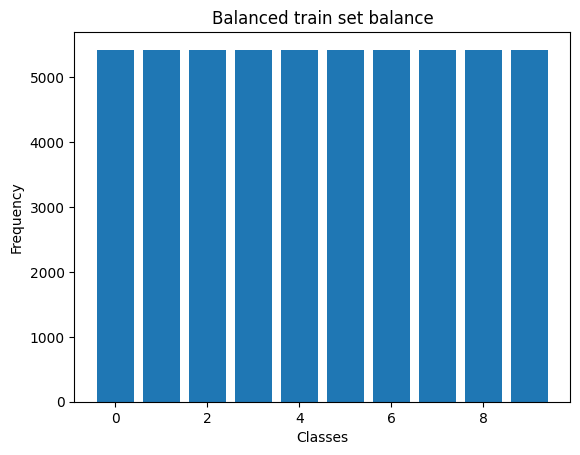

Balaned testing set


100%|██████████| 10/10 [00:00<00:00, 234.84it/s]

(8920, 28, 28)
Minimum label occurence: 892


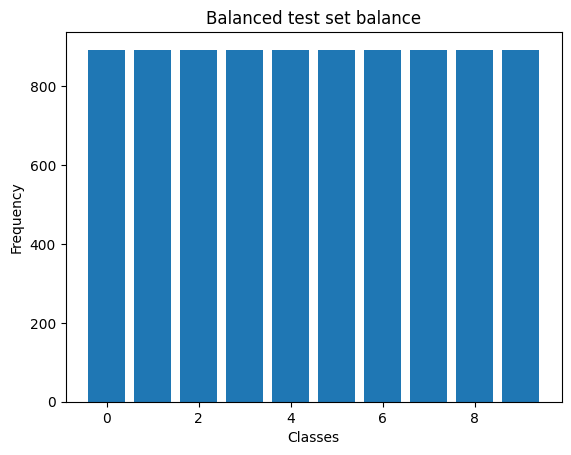

In [7]:
print("Balanced training set")
x_mnist_train, y_mnist_train = balance_dataset(x_mnist_train, y_mnist_train)
print(x_mnist_train.shape)
plot_dataset_balance(y_mnist_train, "Balanced train")

print("Balaned testing set")
x_mnist_test, y_mnist_test = balance_dataset(x_mnist_test, y_mnist_test)
print(x_mnist_test.shape)
plot_dataset_balance(y_mnist_test, "Balanced test")

# Shuffle train set
p = np.random.permutation(y_mnist_train.shape[0])
x_mnist_train = x_mnist_train[p]
y_mnist_train = y_mnist_train[p]

# Shuffle test set
p = np.random.permutation(y_mnist_test.shape[0])
x_mnist_test = x_mnist_test[p]
y_mnist_test = y_mnist_test[p]

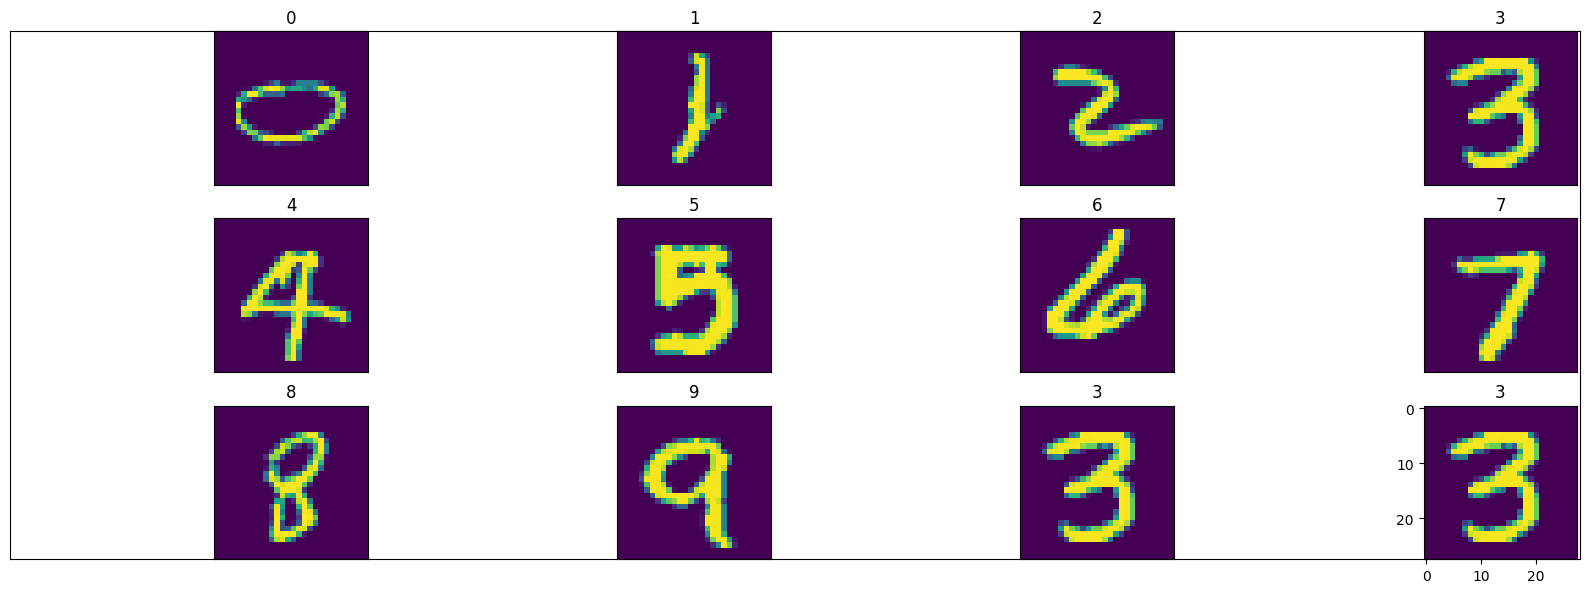

In [8]:
# Print an image of each class
x = np.array([x_mnist_train[np.where(y_mnist_train == i)[0][0]] for i in range(NUM_CLASSES)] + [x_mnist_train[0]]*(NUM_CLASSES%4))
y = np.array([y_mnist_train[np.where(y_mnist_train == i)[0][0]] for i in range(NUM_CLASSES)] + [y_mnist_train[0]]*(NUM_CLASSES%4))
plot_n_images(x.shape[0], x, y)

# MNIST finetuning

In [9]:
EPOCHS        = 20#50
LEARNING_RATE = 1e-3
BATCH_SIZE    = 128#256
LOSS_FUNCTION = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False)
OPTIMIZER     = tf.keras.optimizers.Adam(LEARNING_RATE)

In [28]:
model_mnist = tf.keras.models.Sequential([
    tf.keras.layers.Input((C*H*W,)),
    #tf.keras.layers.Dense(512, activation = "relu"),
    #tf.keras.layers.Dense(256, activation = "relu"),
    tf.keras.layers.Dense(128, activation = "relu"),
    tf.keras.layers.Dense(64, activation = "relu"),
    tf.keras.layers.Dense(10, activation = "softmax")
])
model_mnist.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
OPTIMIZER     = tf.keras.optimizers.Adam(LEARNING_RATE)
model_mnist.compile(
    optimizer = OPTIMIZER,
    loss      = LOSS_FUNCTION,
    metrics   = ["accuracy"]
)

Epoch 1/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8734 - loss: 0.4372 - val_accuracy: 0.9166 - val_loss: 0.2654
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9364 - loss: 0.2112 - val_accuracy: 0.9488 - val_loss: 0.1656
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9538 - loss: 0.1541 - val_accuracy: 0.9572 - val_loss: 0.1403
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9614 - loss: 0.1271 - val_accuracy: 0.9637 - val_loss: 0.1164
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9677 - loss: 0.1043 - val_accuracy: 0.9687 - val_loss: 0.1050
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9716 - loss: 0.0908 - val_accuracy: 0.9649 - val_loss: 0.1153
Epoch 7/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9748 - loss: 0.0797 - val_accuracy: 0.9702 - val_loss: 0.0988
Epoch 8/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9767 - loss: 0.0718 - val_accuracy: 0.

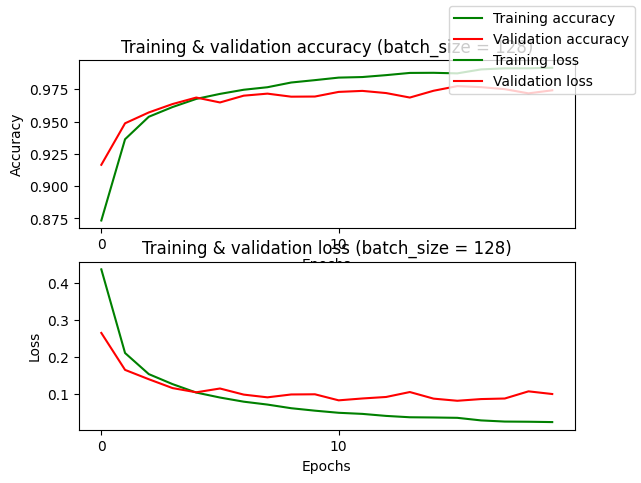

In [36]:
x_mnist_train = flatten_dataset(x_mnist_train)
#y_mnist_train = to_categorical(y_mnist_train)

x_mnist_test = flatten_dataset(x_mnist_test)
#y_mnist_test = to_categorical(y_mnist_test)

history_mnist = model_mnist.fit(
    x_mnist_train,
    y_mnist_train,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    validation_data  = (x_mnist_test, y_mnist_test)
)

plot_accuracy_loss(history_mnist, EPOCHS, BATCH_SIZE)

In [37]:
print("Evaluation on train set : ")
model_mnist.evaluate(x_mnist_train, y_mnist_train, verbose=2)

print("Evaluation on test set : ")
model_mnist.evaluate(x_mnist_test, y_mnist_test, verbose=2)

Evaluation on train set : 
1695/1695 - 4s - 2ms/step - accuracy: 0.9930 - loss: 0.0220
Evaluation on test set : 
279/279 - 1s - 2ms/step - accuracy: 0.9743 - loss: 0.1003


[0.10033559799194336, 0.9743273258209229]

279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


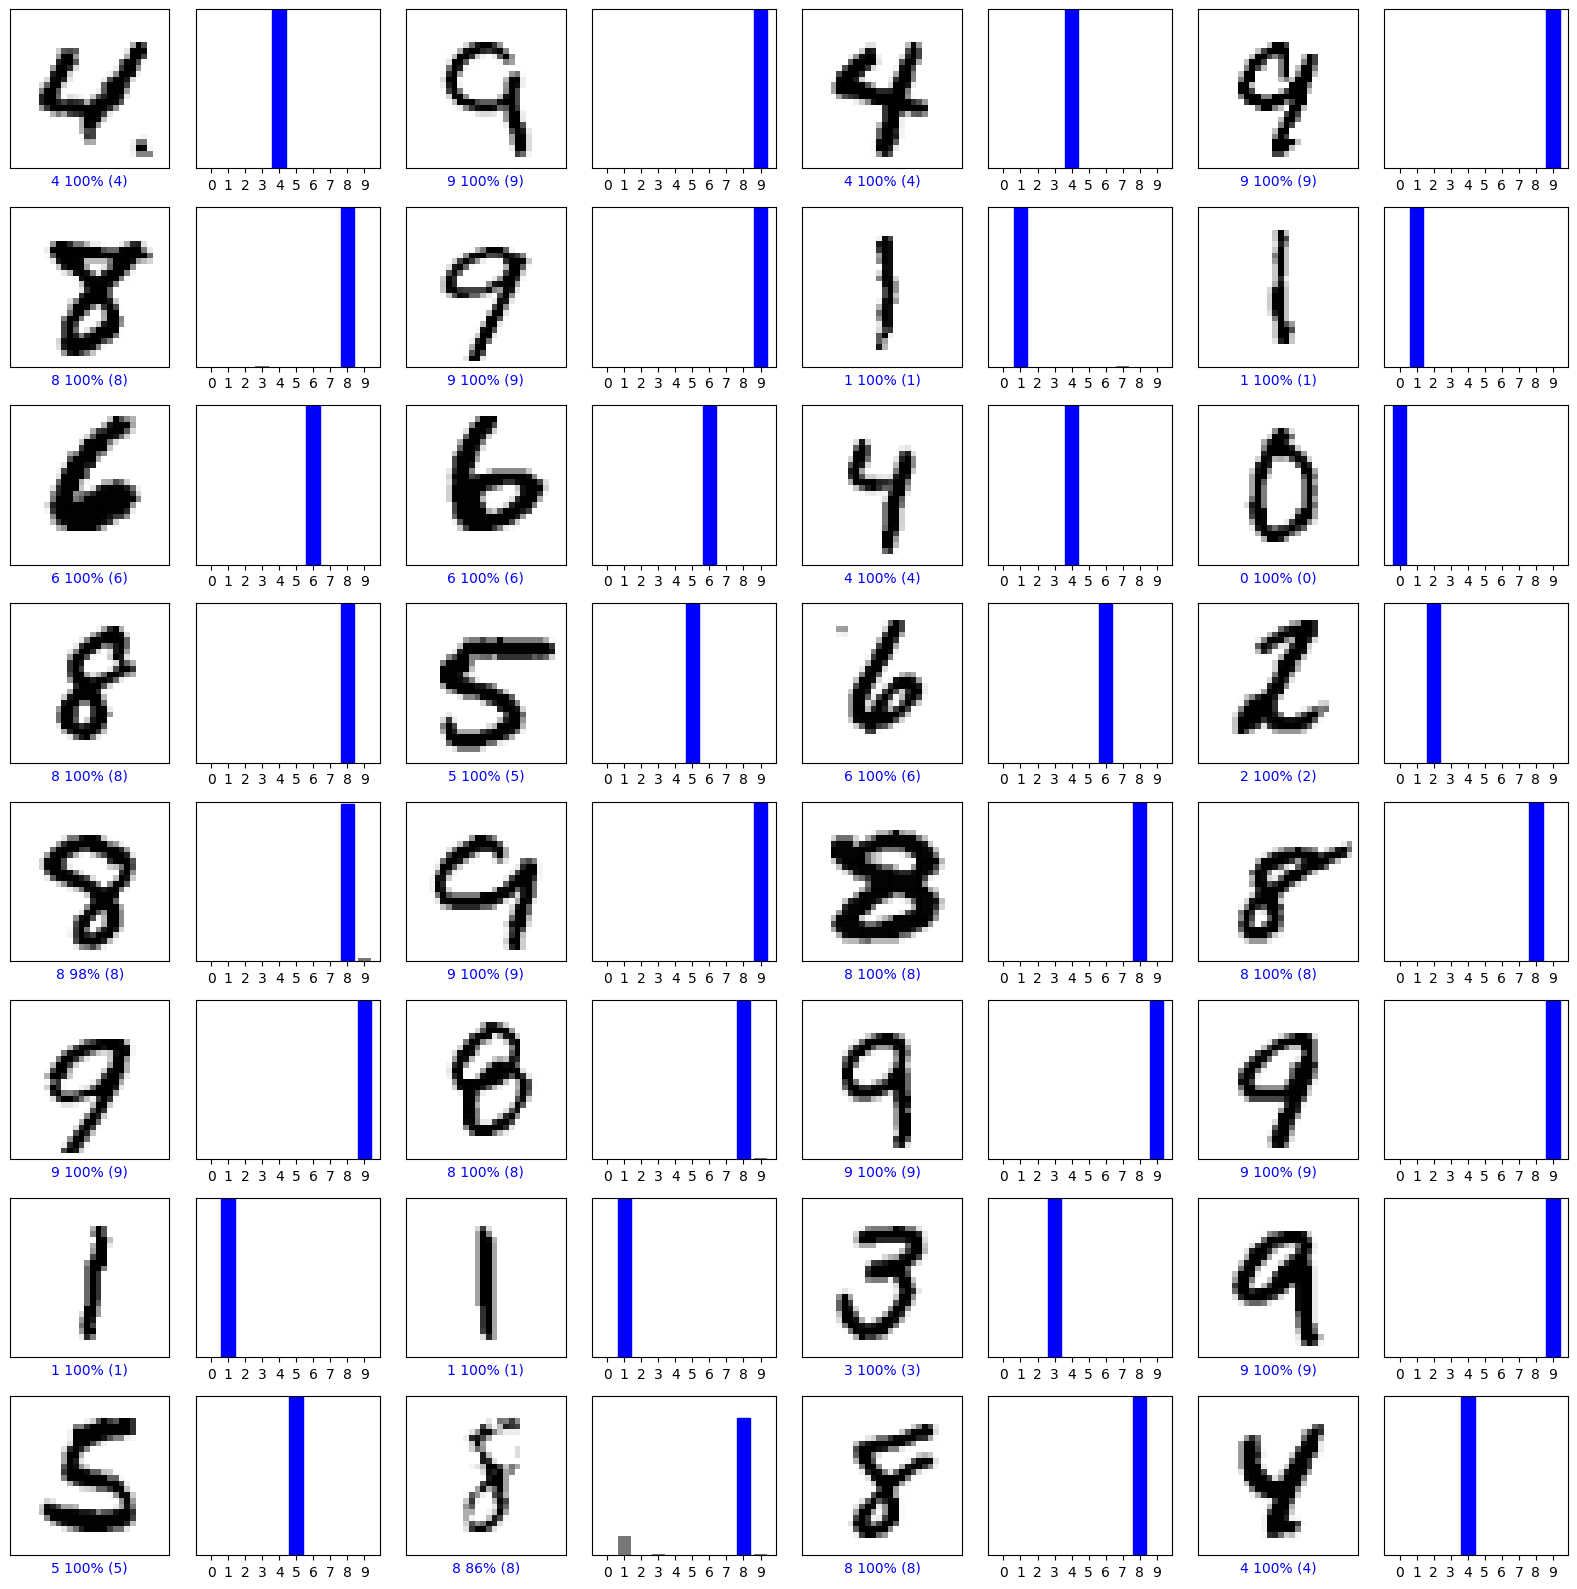

In [38]:
predictions = model_mnist.predict(x_mnist_test)
print_prediction(32, x_mnist_test.reshape((-1, H, W))+0.5, y_mnist_test, predictions, num_classes = NUM_CLASSES)

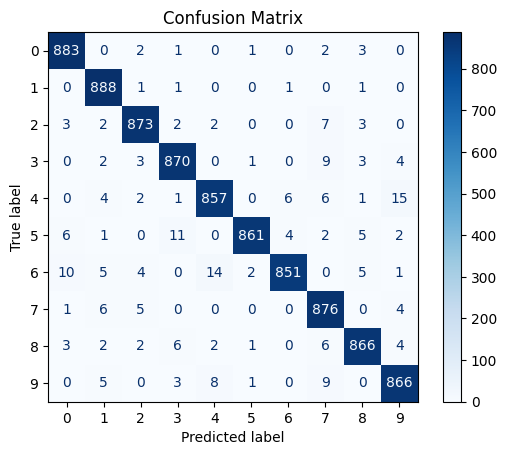

In [39]:
cm = confusion_matrix(y_mnist_test, np.argmax(predictions, axis = 1))
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [str(i) for i in range(NUM_CLASSES)])
disp.plot(cmap = 'Blues')
plt.title("Confusion Matrix")
plt.show()

In [46]:
# Save model and its metadata
model_name = "5dense-mnist-10class-finetuned_1"
model_mnist.save(model_name + ".h5")
with open(model_name + "-history.json", "w") as f:
    json.dump(history_mnist.history, f)

In [47]:
# Reload model and its metadata
model_mnist_name = "5dense-mnist-10class-finetuned"
model_mnist = tf.keras.models.load_model(model_mnist_name + ".h5")
class History:
    def __init__(self):
        self.history = {}
        self.epoch   = 0
history_mnist = History()
with open(model_mnist_name + "-history.json", 'r') as f:
    history_mnist.history = json.load(f)
history_mnist.epoch       = list(range(len(history_mnist.history["loss"])))

# Model deployment using AIfES-Converter

In [42]:
# NUM_CLASSES = 10
# #NUM_PICTURES = 10
# #x_mnist_train = x_mnist_train[:NUM_PICTURES]
# #x_mnist_test = x_mnist_test[:NUM_PICTURES]
# #y_mnist_train = y_mnist_train[:NUM_PICTURES]
# #y_mnist_test = y_mnist_test[:NUM_PICTURES]

In [43]:
# BASE_PATH     = "."
# MODEL          = model_mnist
# MODEL_TYPE     = "mlp"
# DATASET_NAME   = "mnist"
# LOSS_NAME      = "crossentropy"
# OPTIMIZER_NAME = "adam"#"sgd"
# FROZEN_LAYERS = [False, False, False, False, False]
# WITH_WEIGHTS = True

# CONVERT_DATASET = False

# frozen_layers  = FROZEN_LAYERS
# with_weights   = WITH_WEIGHTS
# train_set_size = x_mnist_train.shape[0]
# test_set_size  = x_mnist_test.shape[0]
# test_name      = DATASET_NAME + "-" + MODEL_TYPE + "-" + str(len(MODEL.layers)) + "layers" + "-" + str(frozen_layers.count(True)) + "frozen" + "-" + ("pretrained" if with_weights else "untrained") + "-" + LOSS_NAME + "-" + OPTIMIZER_NAME

# # F32 deployment
# keras2aifes.convert_to_fnn_f32(
#     MODEL,
#     BASE_PATH + "/f32/" + test_name,
#     train_set_size,
#     test_set_size,
#     with_weights = with_weights,
#     loss = LOSS_NAME,
#     optimizer = OPTIMIZER_NAME,
#     with_frozen_layers = False,
#     frozen_layers = frozen_layers
# )
# if(CONVERT_DATASET):
#     dataset2flatbuffer.dataset2flatbuffer(
#         BASE_PATH + "/dataset/" + DATASET_NAME + "-f32",
#         32,
#         x_mnist_train,
#         y_mnist_train,
#         x_mnist_test,
#         y_mnist_test,
#         num_classes = NUM_CLASSES
#     )
